# 10 — Factuality distribution (by work)

Clean non-historian works classified on a 4-level factuality scale based
on the *type* of evidence they provide about contemporary social rules.

| Score | Type of evidence | Example |
|---|---|---|
| 1 | Tragedy, myth, epic, or speculative framing. The rule reflects the author's era only obliquely. | Sophocles' *Antigone* on burial rights |
| 2 | Contemporary prose, poems or treatises implying the rule exists in the author's own society without quoting it. | Aristotle describing the selection of archons in the *Athenaion Politeia* |
| 3 | Court speech or oration invoking a specific extant law or procedure. | Demosthenes' speeches |
| 4 | Original legal text, statute, or constitutional clause quoted verbatim. | Draco's Homicide Law |

Raw 1–5 scores from `works_factuality_v18.tsv` are remapped
`1 → 1`, `2 → 2`, `3 → 2`, `4 → 3`, `5 → 4` (old *indirect inference* merged
into *contemporary documentation*).

**Source**: `data/llm_results/works_factuality_v18.tsv`.

*Follows `notebook_rule.md`.*

## 1. Setup — imports, style, constants

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

WORKS_TSV = Path('../data/clean/final/works_factuality_v18.tsv')

FACT_REMAP = {1: 1, 2: 2, 3: 2, 4: 3, 5: 4}

LABELS = {
    1: '1 — Tragedy / myth / speculative',
    2: '2 — Contemporary prose, poems or treatises',
    3: '3 — Court speech / oration',
    4: '4 — Original legal text',
}

In [2]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'Helvetica',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'legend.frameon': False,
})

BAR = '#4a7a9b'

## 2. Load data

In [3]:
df_raw = pd.read_csv(WORKS_TSV, sep='\t')
print(f'Loaded {len(df_raw):,} works from {WORKS_TSV.name}')
df_raw[['perseus_id', 'factuality']].head()

Loaded 391 works from works_factuality_v18.tsv


,perseus_id,factuality
0,tlg0006.tlg009,1
1,tlg0006.tlg007,1
2,tlg0006.tlg001,1
3,tlg0006.tlg006,1
4,tlg0006.tlg008,1


## 3. Preprocessing — remap raw 1–5 scale to 1–4

In [4]:
df = df_raw.copy()
df['factuality_raw'] = df['factuality']
df['factuality'] = df['factuality'].map(FACT_REMAP)

assert df['factuality'].between(1, 4).all(), 'factuality outside 1–4'
assert df['factuality'].notna().all(), 'missing factuality score'

print('Raw → remapped transitions:')
print(df.groupby('factuality_raw')['factuality'].first().to_string())
print(f'\nClassified works: {len(df):,}')
df[['perseus_id', 'factuality_raw', 'factuality']].head()

Raw → remapped transitions:
factuality_raw
1    1
2    2
3    2
4    3

Classified works: 391


,perseus_id,factuality_raw,factuality
0,tlg0006.tlg009,1,1
1,tlg0006.tlg007,1,1
2,tlg0006.tlg001,1,1
3,tlg0006.tlg006,1,1
4,tlg0006.tlg008,1,1


## 4. Counts table

In [5]:
counts = df['factuality'].value_counts().reindex(range(1, 5), fill_value=0)
total = int(counts.sum())

tbl = counts.to_frame('works')
tbl['%'] = (100 * tbl['works'] / total).round(1)
tbl['label'] = [LABELS[i] for i in tbl.index]
tbl

,works,%,label
factuality,,,
1,73,18.7,1 — Tragedy / myth / speculative
2,166,42.5,"2 — Contemporary prose, poems or treatises"
3,152,38.9,3 — Court speech / oration
4,0,0.0,4 — Original legal text


## 5. Figures

### Figure 1: Factuality distribution (by work)

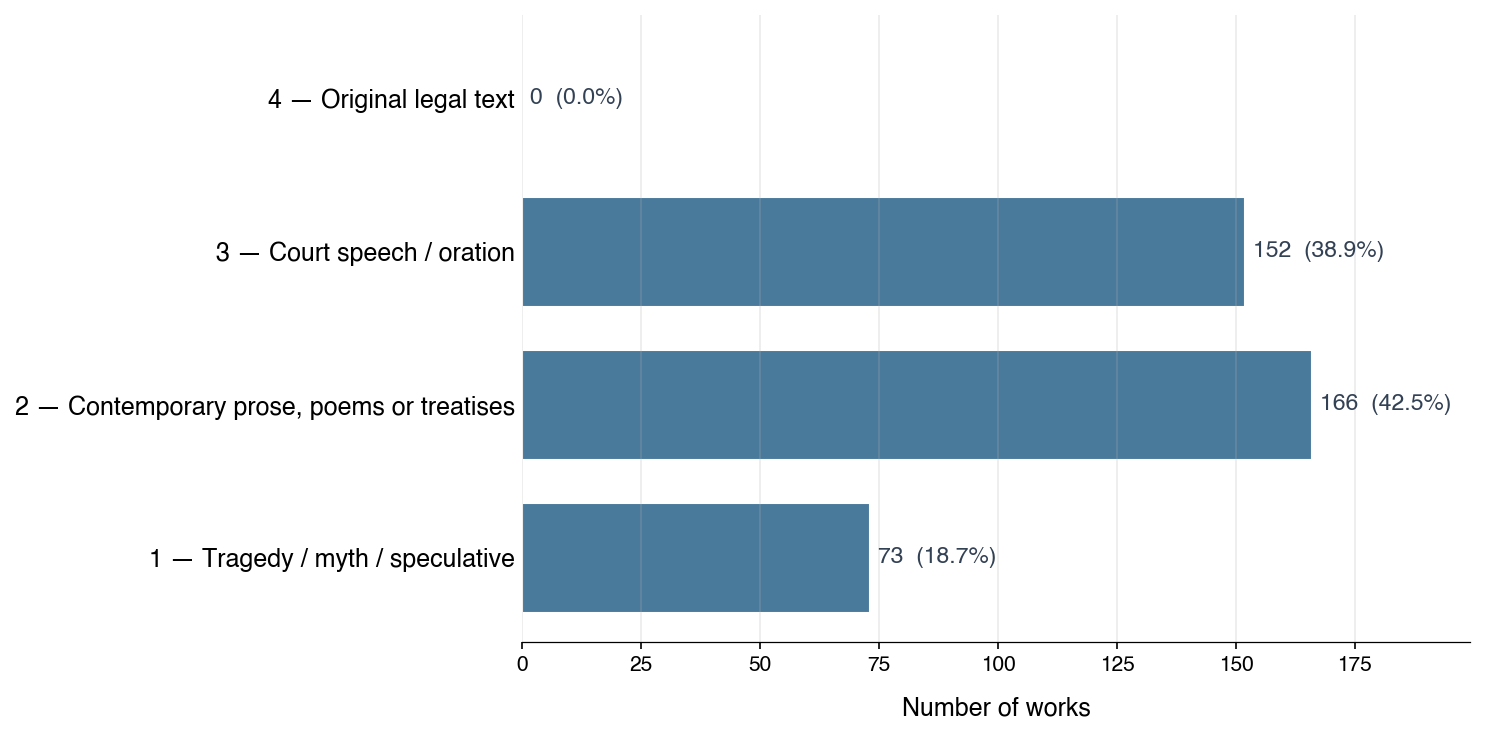

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

y = range(4, 0, -1)
labels = [LABELS[i] for i in range(4, 0, -1)]
values = [int(counts.get(i, 0)) for i in range(4, 0, -1)]

ax.barh(y, values, color=BAR, edgecolor='white', height=0.72)

for yi, v in zip(y, values):
    pct = v / total * 100 if total else 0
    ax.text(v + max(values) * 0.01, yi,
            f'{v:,}  ({pct:.1f}%)',
            va='center', fontsize=11, color='#334155')

ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Number of works', fontsize=12, labelpad=10)
ax.set_xlim(0, max(values) * 1.2)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right', 'left']].set_visible(False)
fig.tight_layout()